In [1]:
import pandas as pd
df=pd.read_csv("Advertising.csv")
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [4]:
x=df.iloc[:,1:4]
y=df["Sales"]
print(x.shape)
print(y.shape)

(200, 3)
(200,)


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(160, 3)
(160,)
(40, 3)
(40,)


In [6]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
ypred=lr.predict(x_test)
diff=pd.DataFrame({"Actual":y_test,"Predicted":ypred})
diff

,Actual,Predicted
58,23.8,21.735772
40,16.6,16.456938
34,9.5,7.659932
102,14.8,17.892027
184,17.6,18.677307
198,25.5,23.862719
95,16.9,16.336236
4,12.9,13.456492
29,10.5,9.177296
168,17.1,17.360562


In [7]:
print("coefficient:",lr.coef_)
print("intercept:",lr.intercept_)

coefficient: [0.0468431  0.17854434 0.00258619]
intercept: 2.9079470208164295


In [8]:
from sklearn import metrics
print("MAE:",metrics.mean_absolute_error(y_test,ypred))
print("MSE:",metrics.mean_squared_error(y_test,ypred))
print("R2 Score:",metrics.r2_score(y_test,ypred))

MAE: 1.0402154012924718
MSE: 1.9918855518287906
R2 Score: 0.8927605914615384


In [14]:
import pandas as pd
df=pd.read_csv("FuelConsumptionCo2.csv")
df

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [15]:
df.drop(columns=["MODELYEAR","MAKE","MODEL","TRANSMISSION"],axis=1,inplace=True)
df

,VEHICLECLASS,ENGINESIZE,CYLINDERS,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,COMPACT,2.0,4,Z,9.9,6.7,8.5,33,196
1,COMPACT,2.4,4,Z,11.2,7.7,9.6,29,221
2,COMPACT,1.5,4,Z,6.0,5.8,5.9,48,136
3,SUV - SMALL,3.5,6,Z,12.7,9.1,11.1,25,255
4,SUV - SMALL,3.5,6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...
1062,SUV - SMALL,3.0,6,X,13.4,9.8,11.8,24,271
1063,SUV - SMALL,3.2,6,X,13.2,9.5,11.5,25,264
1064,SUV - SMALL,3.0,6,X,13.4,9.8,11.8,24,271
1065,SUV - SMALL,3.2,6,X,12.9,9.3,11.3,25,260


In [16]:
df.corr(numeric_only=True)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [20]:
x=df[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB"]]
y=df["CO2EMISSIONS"]
print(x.shape)
print(y.shape)

(1067, 3)
(1067,)


In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(853, 3)
(853,)
(214, 3)
(214,)


In [22]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
ypred=lr.predict(x_test)
diff=pd.DataFrame({"Actual":y_test,"Predicted":ypred})
diff

,Actual,Predicted
133,274,257.072975
340,200,193.626754
948,196,198.619472
704,161,184.031563
661,320,308.848870
...,...,...
961,301,275.681075
523,184,189.131654
884,274,266.323339
8,267,262.249461


In [23]:
print("coefficient:",lr.coef_)
print("intercept:",lr.intercept_)

coefficient: [11.56295409  6.91231122  9.72527271]
intercept: 65.17950048137254


In [24]:
from sklearn import metrics
print("MAE:",metrics.mean_absolute_error(y_test,ypred))
print("MSE:",metrics.mean_squared_error(y_test,ypred))
print("R2 Score:",metrics.r2_score(y_test,ypred))

MAE: 16.64682799882323
MSE: 546.2591396903438
R2 Score: 0.8653355812644816


## Polynomial Linear Regression


In [25]:
df=pd.read_csv("polylinearregression.csv")
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [27]:
x=df[["Temperature"]]
y=df["Pressure"]
print(x.shape)
print(y.shape)

(6, 1)
(6,)


In [32]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
ypred=lr.predict(x)
diff=pd.DataFrame({"Actual":y,"Predicted":ypred})
diff

,Actual,Predicted
0,0.0002,-0.050867
1,0.0012,-0.004027
2,0.0060,0.042813
3,0.0300,0.089653
4,0.0900,0.136493
5,0.2700,0.183333


In [33]:
print("coefficient:",lr.coef_)
print("intercept:",lr.intercept_)

coefficient: [0.002342]
intercept: -0.05086666666666667


In [35]:
from sklearn import metrics
print("MAE:",metrics.mean_absolute_error(y,ypred))
print("MSE:",metrics.mean_squared_error(y,ypred))
print("R2 Score:",metrics.r2_score(y,ypred))

MAE: 0.047653333333333346
MSE: 0.002870267555555557
R2 Score: 0.690349972603981


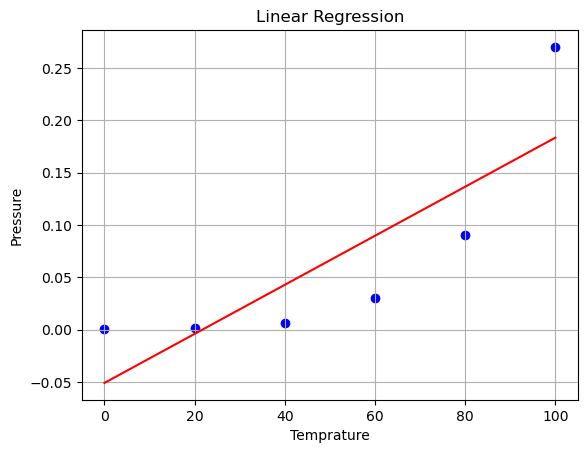

In [38]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color="blue")
plt.plot(x,ypred,color="red")
plt.xlabel("Temprature")
plt.ylabel("Pressure")
plt.title("Linear Regression")
plt.grid(True)
plt.show()

In [60]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
x_poly=poly.fit_transform(x)
print(x_poly)

[[1.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [1.00e+00 2.00e+01 4.00e+02 8.00e+03]
 [1.00e+00 4.00e+01 1.60e+03 6.40e+04]
 [1.00e+00 6.00e+01 3.60e+03 2.16e+05]
 [1.00e+00 8.00e+01 6.40e+03 5.12e+05]
 [1.00e+00 1.00e+02 1.00e+04 1.00e+06]]


In [61]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_poly,y)
ypred=lr.predict(x_poly)
ypred

array([-0.00198889,  0.00724444,  0.00371111,  0.02248889,  0.09865556,
        0.26728889])

In [62]:
from sklearn import metrics
print("MAE:",metrics.mean_absolute_error(y,ypred))
print("MSE:",metrics.mean_squared_error(y,ypred))
print("R2 Score:",metrics.r2_score(y,ypred))

MAE: 0.004899999999994181
MSE: 3.0875185185185205e-05
R2 Score: 0.9966691251761722


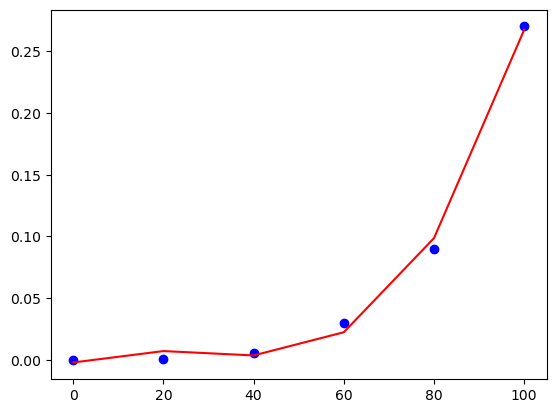

In [63]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color="blue")
plt.plot(x,ypred,color="red")
plt.show()

In [64]:
df=pd.read_csv("car_data.csv")
df

,Horsepower,Weight,MPG
0,130,3504,18
1,165,3693,15
2,150,3436,18
3,140,3433,16
4,198,4341,14
5,220,4354,12
6,95,2372,25
7,88,2130,27
8,98,2228,24


In [65]:
y=df["MPG"]
x=df[["Horsepower","Weight"]]
print(x.shape)
print(y.shape)

(9, 2)
(9,)


In [72]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x)

In [73]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_poly,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(7, 6)
(7,)
(2, 6)
(2,)


In [74]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
ypred=lr.predict(x_test)
ypred

array([25.53716178, 15.7560762 ])

In [94]:
x=[1,2,3,4,5]
y=[1,4,9,16,25]
x=pd.DataFrame(x)
y=pd.Series(y)

In [103]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x)

In [104]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_poly,y)
ypred=lr.predict(x_poly)
ypred

array([ 1.,  4.,  9., 16., 25.])

In [105]:
diff=pd.DataFrame({"Actual":y,"Predicted":ypred})
diff

,Actual,Predicted
0,1,1.0
1,4,4.0
2,9,9.0
3,16,16.0
4,25,25.0


In [106]:
from sklearn import metrics
print("MAE:",metrics.mean_absolute_error(y,ypred))
print("MSE:",metrics.mean_squared_error(y,ypred))
print("R2 Score:",metrics.r2_score(y,ypred))

MAE: 4.174438572590589e-15
MSE: 3.1751651435145725e-29
R2 Score: 1.0
